In [14]:
# Cell 0: Environment setup and library installation
# Run this once if the required packages are not yet installed in your environment
!pip install bambi arviz pymc matplotlib seaborn pandas numpy


In [15]:
# Cell 1: Import required scientific and Bayesian libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import bambi as bmb

# Configure publication-grade styling for plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")


All libraries imported successfully!


In [16]:
# Cell 2: Data ingestion, inspection, and structural cleaning
# Load the raw Belenky et al. (2003) sleep deprivation dataset
df_raw = pd.read_csv("Real Sleep.csv")

# Standardize column naming: remove spaces and units for formula safety
df = df_raw.rename(columns={
    'Reaction_Time (ms)': 'Reaction_Time',
    'Sleep_Hours_Allowed (h/night)': 'Sleep_Hours_Allowed',
    'Baseline_Reaction_Time (ms)': 'Baseline_Reaction_Time'
})

# Drop degenerate or missing columns:
# - Lapses_Count: contains almost exclusively missing values (NaN)
# - Sleep_Hours_Allowed: constant fixed design parameter (3h across all subjects)
cols_to_drop = ['Lapses_Count', 'Sleep_Hours_Allowed']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Explicitly cast 'Subject' identifier to string/category to prevent treated as continuous numeric
df['Subject'] = df['Subject'].astype(str)

# Inspect cleaned dataset properties
print(f"Cleaned dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("Data types:\n", df.dtypes)
print("\nFirst 5 observations:")
display(df.head())


Cleaned dataset shape: 180 rows, 4 columns
Data types:
 Subject                    object
Days                        int64
Reaction_Time             float64
Baseline_Reaction_Time    float64
dtype: object

First 5 observations:


,Subject,Days,Reaction_Time,Baseline_Reaction_Time
0,308,0,249.5600,249.56
1,308,1,258.7047,249.56
2,308,2,250.8006,249.56
3,308,3,321.4398,249.56
4,308,4,356.8519,249.56


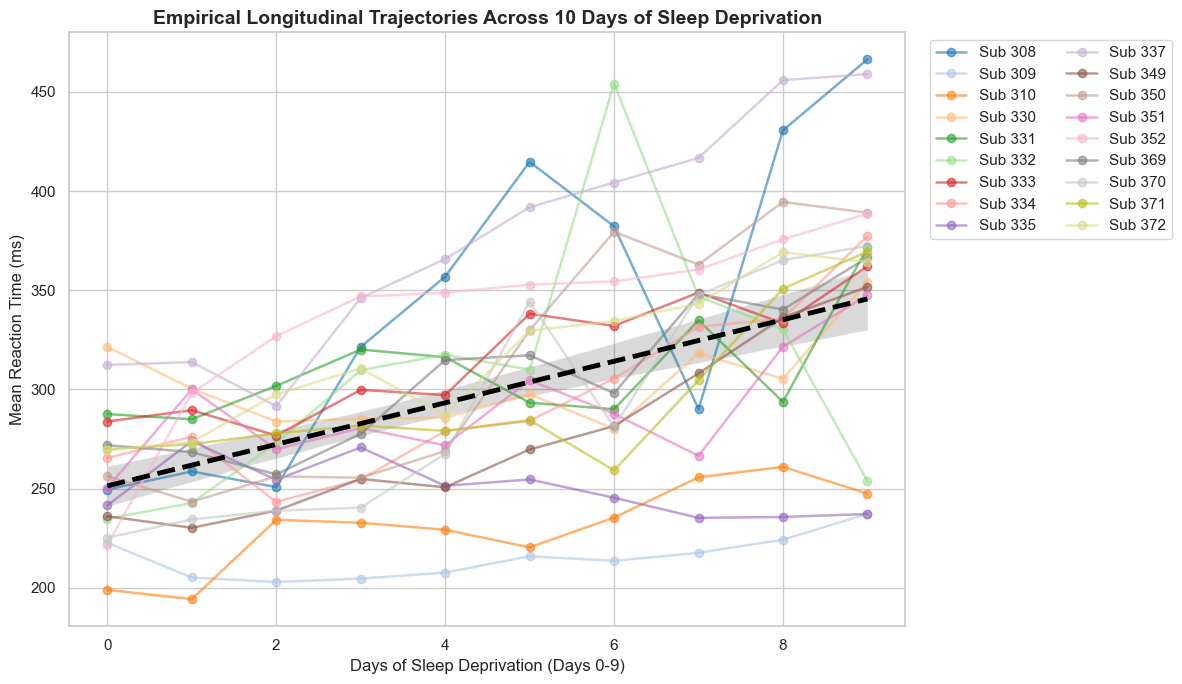

In [17]:
# Cell 3: Exploratory Data Analysis - Individual longitudinal trajectories
fig, ax = plt.subplots(figsize=(12, 7))

# Plot empirical trajectories for each individual subject
palette = sns.color_palette("tab20", n_colors=df['Subject'].nunique())

for idx, (subject_id, subject_data) in enumerate(df.groupby('Subject')):
    ax.plot(
        subject_data['Days'], 
        subject_data['Reaction_Time'], 
        marker='o', 
        alpha=0.6, 
        linewidth=1.8, 
        color=palette[idx],
        label=f"Sub {subject_id}"
    )

# Superimpose the aggregate population trend (OLS mean)
sns.regplot(
    data=df, 
    x='Days', 
    y='Reaction_Time', 
    scatter=False, 
    color='black', 
    line_kws={'linewidth': 3.5, 'linestyle': '--', 'label': 'Population Mean (Pooled)'}, 
    ax=ax
)

ax.set_title("Empirical Longitudinal Trajectories Across 10 Days of Sleep Deprivation", fontsize=14, weight='bold')
ax.set_xlabel("Days of Sleep Deprivation (Days 0-9)", fontsize=12)
ax.set_ylabel("Mean Reaction Time (ms)", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, frameon=True)
plt.tight_layout()
plt.show()


In [18]:
# Cell 4: Hierarchical Bayesian Model Formulation & Markov Chain Monte Carlo (MCMC) Sampling
# Mathematical formulation:
# Level 1 (Within-subject): Reaction_Time_ij ~ Normal(alpha_j + beta_j * Days_ij, sigma^2)
# Level 2 (Between-subject): [alpha_j, beta_j] ~ Multivariate_Normal([mu_alpha, mu_beta], Sigma)

# Define the random intercept & random slope model
model = bmb.Model(
    formula="Reaction_Time ~ Days + (Days | Subject)", 
    data=df, 
    family="gaussian"
)

print("Constructed Bambi Model Architecture:")
print(model)

# Execute Hamiltonian Monte Carlo (NUTS) sampling
print("\nBeginning MCMC posterior sampling...")
idata = model.fit(
    draws=1000,          # Number of samples retained per chain
    tune=1000,           # Warm-up / tuning steps to calibrate step size
    chains=2,            # Independent parallel MCMC sampling chains
    target_accept=0.90,  # Step-size acceptance rate to eliminate divergences
    random_seed=42
)

print("\nSampling completed successfully!")


Initializing NUTS using jitter+adapt_diag...


Constructed Bambi Model Architecture:
       Formula: Reaction_Time ~ Days + (Days | Subject)
        Family: gaussian
          Link: mu = identity
  Observations: 180
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 298.5079, sigma: 261.0092)
            Days ~ Normal(mu: 0.0, sigma: 48.8915)
        
        Group-level effects
            1|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 261.0092))
            Days|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 48.8915))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 56.1721)

Beginning MCMC posterior sampling...


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, Intercept, Days, 1|Subject_sigma, 1|Subject_offset, Days|Subject_sigma, Days|Subject_offset]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



Sampling completed successfully!


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,251.4,7.4,240,270,1290,1296,1.00,0.21,0.17
Days,10.5,1.7,7.1,14,692,804,1.00,0.065,0.042
sigma,25.76,1.54,23,29,2196,1280,1.00,0.033,0.037


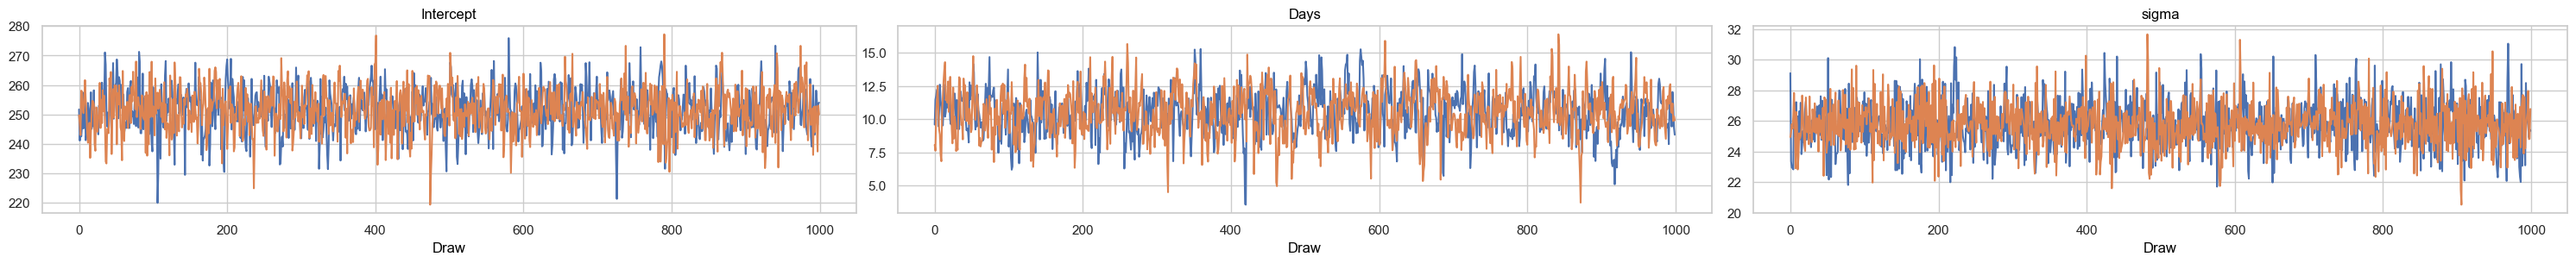

In [19]:
# Cell 5: Convergence diagnostics and posterior summary metrics
# Inspect fixed effects (population parameters) and observational noise (sigma)
summary_table = az.summary(
    idata, 
    var_names=["Intercept", "Days", "sigma"],
    ci_prob=0.95
)

display(summary_table)

# Visual trace diagnostic check to confirm chain convergence (fuzzy caterpillar inspection)
az.plot_trace(
    idata, 
    var_names=["Intercept", "Days", "sigma"], 
    
)
plt.tight_layout()
plt.show()


In [20]:
# Check variable names and shapes in posterior
for k in idata.posterior.data_vars:
    print(k, idata.posterior[k].shape)


sigma (2, 1000)
Intercept (2, 1000)
Days (2, 1000)
1|Subject_sigma (2, 1000)
Days|Subject_sigma (2, 1000)
1|Subject (2, 1000, 18)
Days|Subject (2, 1000, 18)


In [21]:
# Cell 6: Extract and calculate individual subject slopes
# Extract population slope draws and flatten to 1D (2000 draws)
pop_days_draws = idata.posterior["Days"].values.flatten()

# Extract random slope draws for subjects: shape (2, 1000, 18)
slope_offset_array = idata.posterior["Days|Subject"].values

sub_slopes = []
unique_subjects = list(df['Subject'].unique())

for i, sub in enumerate(unique_subjects):
    # Slice the i-th subject across both chains and all draws, then flatten to (2000,)
    offset_draws = slope_offset_array[:, :, i].flatten()
    
    # Subject total slope = Population effect + Individual offset
    total_slope_draws = pop_days_draws + offset_draws
    
    sub_slopes.append({
        "Subject": sub,
        "Mean_Daily_Slowdown_ms": float(np.mean(total_slope_draws)),
        "HDI_2.5": float(np.percentile(total_slope_draws, 2.5)),
        "HDI_97.5": float(np.percentile(total_slope_draws, 97.5))
    })

# Format and rank results by cognitive degradation rate
df_slopes = pd.DataFrame(sub_slopes).sort_values(by="Mean_Daily_Slowdown_ms", ascending=False).reset_index(drop=True)
pop_day_mean = float(pop_days_draws.mean())

print("Cognitive Slowing Rate by Subject (ms per day of deprivation):")
display(df_slopes)



Cognitive Slowing Rate by Subject (ms per day of deprivation):


,Subject,Mean_Daily_Slowdown_ms,HDI_2.5,HDI_97.5
0,308,19.839758,15.167897,24.612784
1,337,19.074635,14.308414,23.928861
2,350,17.253460,12.357457,22.036178
3,370,15.490340,10.978604,20.227132
4,352,13.945946,9.381177,18.709053
5,349,11.822288,7.128939,16.592974
6,372,11.663716,7.121845,16.668594
7,334,11.612341,7.095636,16.438938
8,369,11.346113,6.522337,16.082924
9,333,10.209391,5.740877,14.894891


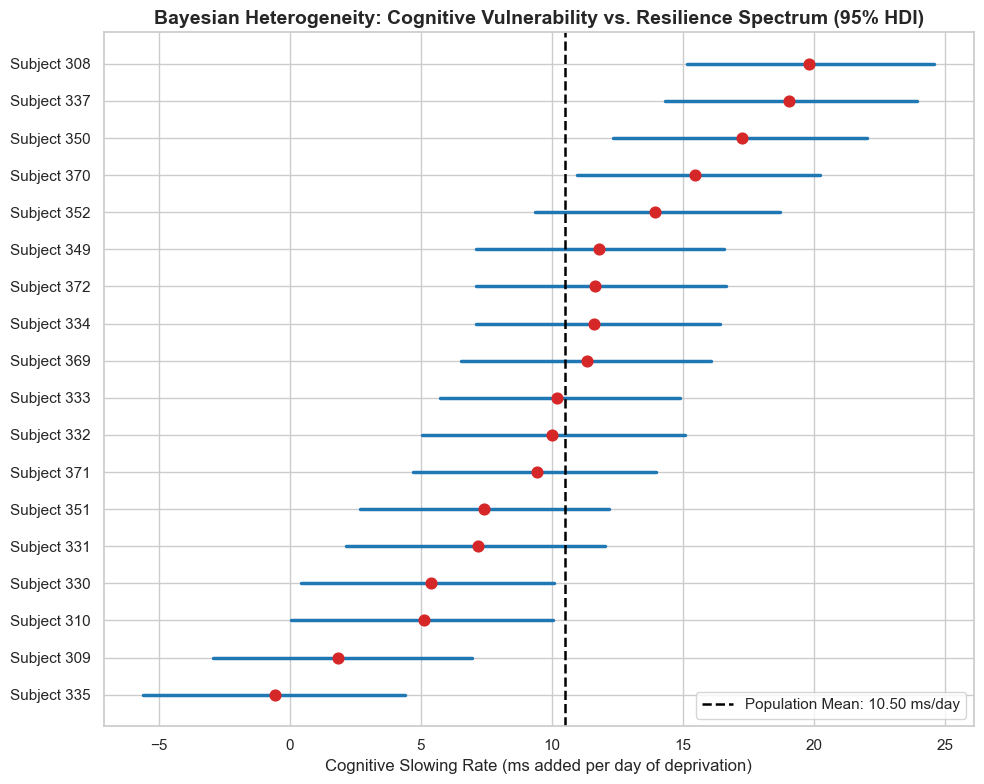

In [22]:
# Cell 7: Publication-grade Forest Plot showing Subject Cognitive Vulnerability Spectrum
fig, ax = plt.subplots(figsize=(10, 8))

y_positions = np.arange(len(df_slopes))

# Plot credible intervals (horizontal error bars)
for i, row in df_slopes.iterrows():
    ax.plot([row['HDI_2.5'], row['HDI_97.5']], [i, i], color='#1f77b4', linewidth=2.5, solid_capstyle='round')
    ax.scatter(row['Mean_Daily_Slowdown_ms'], i, color='#d62728', s=60, zorder=5)

# Vertical line marking population average slowdown
ax.axvline(pop_day_mean, color='black', linestyle='--', linewidth=1.8, label=f"Population Mean: {pop_day_mean:.2f} ms/day")

ax.set_yticks(y_positions)
ax.set_yticklabels([f"Subject {s}" for s in df_slopes['Subject']])
ax.invert_yaxis()  # Most vulnerable at the top
ax.set_xlabel("Cognitive Slowing Rate (ms added per day of deprivation)", fontsize=12)
ax.set_title("Bayesian Heterogeneity: Cognitive Vulnerability vs. Resilience Spectrum (95% HDI)", fontsize=14, weight='bold')
ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig("bayesian_vulnerability_forest_plot.png", dpi=300)
plt.show()


--- Critical Risk Assessment (Day 9, Operational Threshold: 400.0 ms) ---
Subject 308 (Most Vulnerable) Exceedance Probability: 87.0%
Subject 335 (Most Resilient)  Exceedance Probability: 0.0%


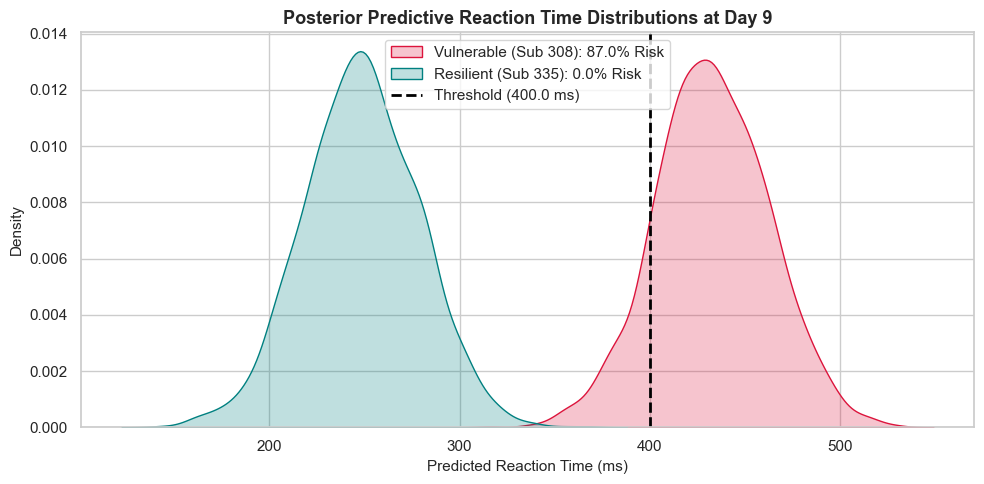

In [23]:
# Cell 8: Predictive risk assessment - Probability of Reaction Time exceeding critical threshold
# Note: 400 ms is used here as an illustrative operational safety benchmark

# Generate posterior predictive samples
model.predict(idata, kind="response")

# Identify the most vulnerable and most resilient subjects
sub_vulnerable = df_slopes.iloc[0]['Subject']
sub_resilient = df_slopes.iloc[-1]['Subject']

# Locate row indices in the dataset corresponding to Day 9 for these subjects
idx_vulnerable = df[(df['Subject'] == str(sub_vulnerable)) & (df['Days'] == 9)].index[0]
idx_resilient = df[(df['Subject'] == str(sub_resilient)) & (df['Days'] == 9)].index[0]

# Extract predicted response distributions for Day 9
pred_vulnerable = idata.posterior_predictive['Reaction_Time'].values[..., idx_vulnerable].flatten()
pred_resilient = idata.posterior_predictive['Reaction_Time'].values[..., idx_resilient].flatten()

threshold_ms = 400.0
prob_risk_vulnerable = np.mean(pred_vulnerable > threshold_ms) * 100
prob_risk_resilient = np.mean(pred_resilient > threshold_ms) * 100

print(f"--- Critical Risk Assessment (Day 9, Operational Threshold: {threshold_ms} ms) ---")
print(f"Subject {sub_vulnerable} (Most Vulnerable) Exceedance Probability: {prob_risk_vulnerable:.1f}%")
print(f"Subject {sub_resilient} (Most Resilient)  Exceedance Probability: {prob_risk_resilient:.1f}%")

# Visualize the posterior predictive risk contrast
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(pred_vulnerable, fill=True, color='crimson', label=f"Vulnerable (Sub {sub_vulnerable}): {prob_risk_vulnerable:.1f}% Risk", ax=ax)
sns.kdeplot(pred_resilient, fill=True, color='teal', label=f"Resilient (Sub {sub_resilient}): {prob_risk_resilient:.1f}% Risk", ax=ax)
ax.axvline(threshold_ms, color='black', linestyle='--', linewidth=2, label=f"Threshold ({threshold_ms} ms)")
ax.set_title("Posterior Predictive Reaction Time Distributions at Day 9", fontsize=13, weight='bold')
ax.set_xlabel("Predicted Reaction Time (ms)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig("safety_threshold_risk_distribution.png", dpi=300)
plt.show()
